<a href="https://colab.research.google.com/github/oszavla/Dirac-Schwarz/blob/main/Potensial_Efektif_Schwarzschild.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np

# Mount Google Drive
drive.mount('/content/drive')
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'

Mounted at /content/drive


# Potensial Schwarzschild

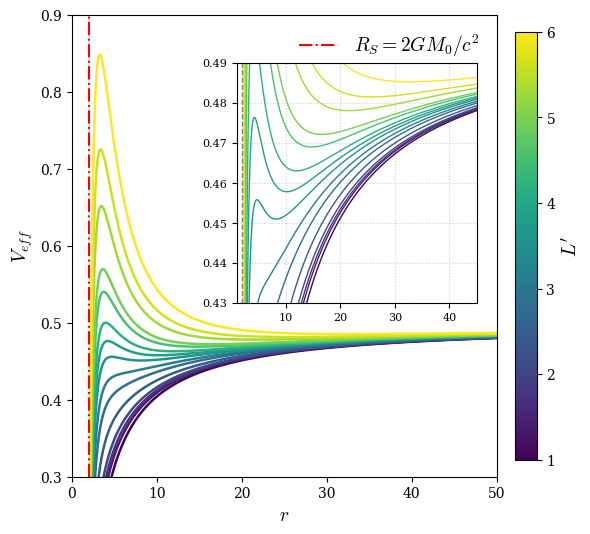

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Konfigurasi Awal ---
save_dir = './'
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# --- Parameter Fisis (Tak Berdimensi) ---
# M = G*M_0/c**2
M = 1
R_s = 2 * M
l_values = [1, 1.5, 1.73, 2.0, 2.5, 3.0, 3.3, 3.6, 3.8, 4.0, 4.3, 4.5, 5, 5.4, 6]

# Definisi grid radial (dimulai tepat dari luar singularitas menuju luar horizon)
r = np.linspace(0.01, 50, 5000)

# --- Inisialisasi Plot ---
fig, ax = plt.subplots(figsize=(6, 6))
colors = cm.viridis(np.linspace(0, 1, len(l_values)))

v_eff_plot_data = []

# --- Perhitungan Potensial ---
with np.errstate(invalid='ignore', divide='ignore'):
    for i, l in enumerate(l_values):
        V_eff = (1/2)*((1-R_s/r)*(1+l**2/r**2))
        V_newton = -M/r +l**2/(2*r**2)
        v_eff_plot_data.append({
            'r': r,
            'V_eff': V_eff,
            'V_newton': V_newton,
            'color': colors[i],
            'l_val': l
        })

# --- Plot Utama ---
for data in v_eff_plot_data:
    ax.plot(data['r'], data['V_eff'], color=data['color'], linewidth=1.8)

ax.set_xlabel(r'$r$', fontsize=14)
ax.set_ylabel(r'$V_{eff}$', fontsize=14)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='-')
ax.axvline(R_s, color='red', linestyle='-.', linewidth=1.5, label=r'$R_S = 2GM_0/c^2$')


# Legend dan Colorbar
ax.legend(loc='upper right', fontsize=14, frameon=False)

norm = mcolors.Normalize(vmin=min(l_values), vmax=max(l_values))
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array(l_values)
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label(r'$L^{\prime}$', fontsize=14)
ax.set_xlim(0, 50)
ax.set_ylim(0.3, 0.9)

# --- Inset Zoomed Plot ---
ax_inset = fig.add_axes([0.40, 0.40, 0.40, 0.40]) # Position and size of the inset axes

for data in v_eff_plot_data:
    ax_inset.plot(data['r'], data['V_eff'], color=data['color'], linewidth=1.0)

ax_inset.axvline(2 * M, color='gray', linestyle='--', linewidth=1.0)
ax_inset.set_xlim( M, 45 * M) # Zoomed x-limits
ax_inset.set_ylim(0.43, 0.49) # Zoomed y-limits
ax_inset.tick_params(axis='both', which='major', labelsize=8)
ax_inset.grid(True, linestyle=':', alpha=0.6) # Add a grid to the inset

#plt.tight_layout()
filename = os.path.join(save_dir, 'Effective_Potential_Schwarzschild.png')
plt.savefig(filename, dpi=350, bbox_inches='tight')
plt.show()

# Potensial Dirac-Swarzschild

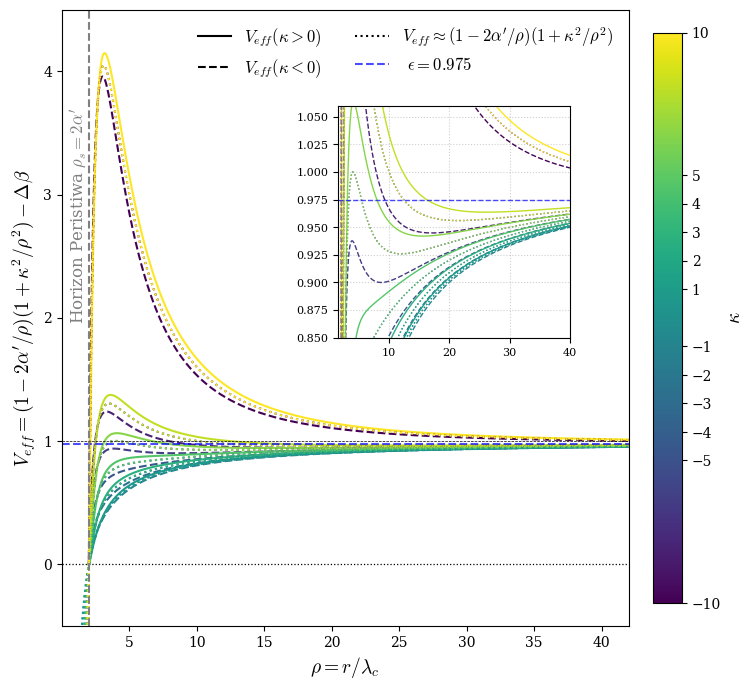

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
from IPython.display import display
import warnings

save_dir = './'
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'


# Define Parameters
alpha_prime = 1.0               # Scale parameter (GM)
epsilon = 0.975               # Energy to rest mass ratio
kappas = [-10, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 10] # Renamed for clarity in colorbar
#kappas = [-10, -5, -2, -1, 1, 2, 5, 10]
# Plotting
fig, ax = plt.subplots(figsize=(8, 8)) # Get fig and ax objects
# Create a colormap for different kappa values
colors = cm.viridis(np.linspace(0, 1, len(kappas)))
#colors_neg = cm.Blues(np.linspace(0.4, 1, len(kappas_neg))) if kappas_neg else []
#colors_pos = cm.Oranges(np.linspace(0.4, 1, len(kappas_pos))) if kappas_pos else []
# Define the radial grid (starts just outside the event horizon rho = 2*alpha')
rho = np.linspace(0.0001 * alpha_prime, 50 * alpha_prime, 20000)
f = 1 - 2 * alpha_prime / rho   # Schwarzschild Metric

# Dictionary to store all calculated roots for later display
all_calculated_roots = {}

# Lists to store plotting data for both main and inset plots
v_eff_plot_data = []
v_eff_approx_plot_data = []
delta_beta_plot_data = []


with np.errstate(invalid='ignore', divide='ignore'):
  for i, kappa in enumerate(kappas):

      delta_beta   = kappa * np.sqrt(f) * ( (alpha_prime / rho**3) / (1 + np.sqrt(f) / epsilon) - (f / rho**2) )
      V_eff        = f * (1 + kappa**2 / rho**2) - delta_beta
      V_eff_approx = f * (1 + kappa**2 / rho**2)

      linestyle_V_eff = '--' if kappa < 0 else '-'

      # Store data for plotting
      v_eff_plot_data.append({'rho': rho, 'V_eff': V_eff, 'color': colors[i], 'linestyle': linestyle_V_eff})
      v_eff_approx_plot_data.append({'rho': rho, 'V_eff_approx': V_eff_approx, 'color': colors[i]})
      delta_beta_plot_data.append({'rho': rho, 'delta_beta': delta_beta, 'color': colors[i]})


# --- Main Plotting ---
for data in v_eff_plot_data:
    ax.plot(data['rho'], data['V_eff'], color=data['color'], linewidth=1.5, linestyle=data['linestyle'])

for data in v_eff_approx_plot_data:
    ax.plot(data['rho'], data['V_eff_approx'], color=data['color'], linewidth=1.5, linestyle=':')

ax.set_xlabel(r'$\rho = r/\lambda_c $', fontsize=14)
ax.set_ylabel(r'$V_{{eff}}=(1-2\alpha^{\prime}/\rho)(1 + \kappa^2/\rho^2)-\Delta\beta $', fontsize=14) #$\Delta\beta$,

# Add axhline for epsilon, with a label
ax.axhline(1, color='black', linewidth=0.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.9, linestyle=':')
ax.axhline(epsilon, color='blue', linestyle='--', linewidth=1.5, label=rf' $\epsilon = {epsilon}$', alpha=0.7)
ax.axvline( 2 * alpha_prime , color='gray', linestyle='--', linewidth=1.5)
ax.text( 2 * alpha_prime - 1.5 , 2, r'Horizon Peristiwa $\rho_s = 2\alpha^{\prime}$', rotation=90, color='gray', fontsize=12)

# Create proxy artists for the main line styles in the legend
proxy_handles = []
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='-', label=r'$V_{{{eff}}} (\kappa > 0)$'))
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label=r'$V_{{{eff}}} (\kappa < 0)$'))
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label=r'$V_{{{eff}}}\approx(1-2\alpha^{\prime}/\rho)(1 + \kappa^2/\rho^2)$'))


# Get the handle and label for the epsilon line from the existing plot
line_epsilon_handle, line_epsilon_label = ax.get_legend_handles_labels()

# Combine proxy handles with the epsilon line handle
combined_handles = proxy_handles + line_epsilon_handle
combined_labels = [h.get_label() for h in proxy_handles] + line_epsilon_label


# Create the legend
ax.legend(handles=combined_handles, labels=combined_labels, loc='upper right', ncol=2, fontsize=12, frameon=False)

# Create a colorbar for kappa values
norm = mcolors.Normalize(vmin=min(kappas), vmax=max(kappas))
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array(kappas) # The array data must be set to ensure color mapping
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label(r'$\kappa$', fontsize=14)
cbar.set_ticks(kappas) # Set integer ticks
ax.set_ylim(-0.5, 4.5)
ax.set_xlim(rho.min(), rho.max())


# --- Inset Zoomed Plot ---
ax_inset = fig.add_axes([0.47, 0.47, 0.29, 0.29]) # Position and size of the inset axes

for data in v_eff_plot_data:
    ax_inset.plot(data['rho'], data['V_eff'], color=data['color'], linewidth=1.0, linestyle=data['linestyle'])

for data in v_eff_approx_plot_data:
    ax_inset.plot(data['rho'], data['V_eff_approx'], color=data['color'], linewidth=1.0, linestyle=':')

ax_inset.axhline(epsilon, color='blue', linestyle='--', linewidth=1.0, alpha=0.7)
ax_inset.axvline(2 * alpha_prime, color='gray', linestyle='--', linewidth=1.0)
ax_inset.set_xlim(1.5 * alpha_prime, 50 * alpha_prime) # Zoomed x-limits
ax_inset.set_ylim(0.85, 1.06) # Zoomed y-limits
ax_inset.tick_params(axis='both', which='major', labelsize=8)
ax_inset.grid(True, linestyle=':', alpha=0.6) # Add a grid to the inset


filename = os.path.join(save_dir, f'Effective_potential_{epsilon:.3f}.png')
plt.savefig(filename, dpi=350)
plt.show()

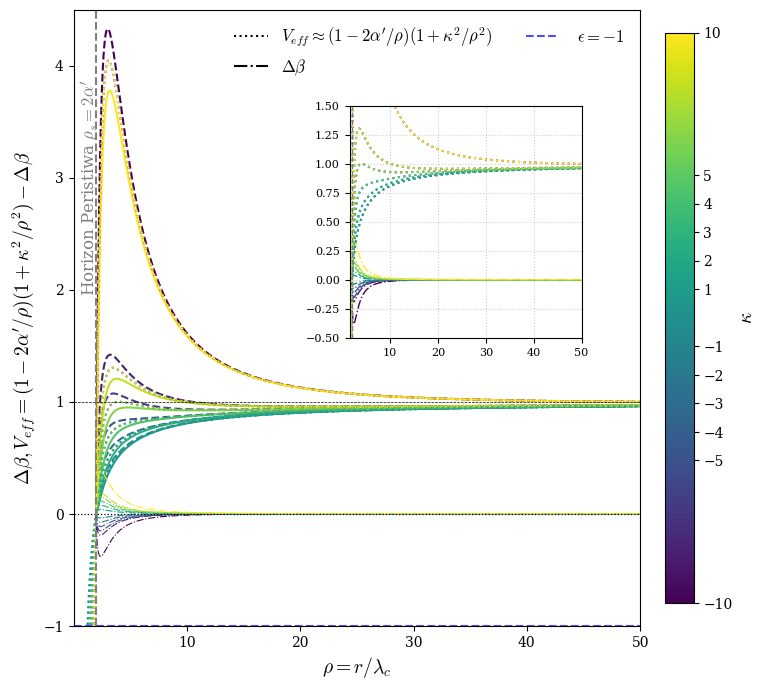

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
from IPython.display import display
import warnings

save_dir = './'
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'


# Define Parameters
alpha_prime = 1.0               # Scale parameter (GM)
epsilon = -1               # Energy to rest mass ratio
kappas = [-10, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 10] # Renamed for clarity in colorbar
#kappas = [-10, -5, -2, -1, 1, 2, 5, 10]
# Plotting
fig, ax = plt.subplots(figsize=(8, 8)) # Get fig and ax objects
# Create a colormap for different kappa values
colors = cm.viridis(np.linspace(0, 1, len(kappas)))
#colors_neg = cm.Blues(np.linspace(0.4, 1, len(kappas_neg))) if kappas_neg else []
#colors_pos = cm.Oranges(np.linspace(0.4, 1, len(kappas_pos))) if kappas_pos else []
# Define the radial grid (starts just outside the event horizon rho = 2*alpha')
rho = np.linspace(0.0001 * alpha_prime, 50 * alpha_prime, 20000)
f = 1 - 2 * alpha_prime / rho   # Schwarzschild Metric

# Dictionary to store all calculated roots for later display
all_calculated_roots = {}

# Lists to store plotting data for both main and inset plots
v_eff_plot_data = []
v_eff_approx_plot_data = []
delta_beta_plot_data = []
root_plot_data = []

with np.errstate(invalid='ignore', divide='ignore'):
  for i, kappa in enumerate(kappas):

      delta_beta   = kappa * np.sqrt(f) * ( (alpha_prime / rho**3) / (1 + np.sqrt(f) / epsilon) - (f / rho**2) )
      V_eff        = f * (1 + kappa**2 / rho**2) - delta_beta
      V_eff_approx = f * (1 + kappa**2 / rho**2)

      linestyle_V_eff = '--' if kappa < 0 else '-'

      # Store data for plotting
      v_eff_plot_data.append({'rho': rho, 'V_eff': V_eff, 'color': colors[i], 'linestyle': linestyle_V_eff})
      v_eff_approx_plot_data.append({'rho': rho, 'V_eff_approx': V_eff_approx, 'color': colors[i]})
      delta_beta_plot_data.append({'rho': rho, 'delta_beta': delta_beta, 'color': colors[i]})



# --- Main Plotting --- (after collecting all data)
for data in v_eff_plot_data:
    ax.plot(data['rho'], data['V_eff'], color=data['color'], linewidth=1.5, linestyle=data['linestyle'])

for data in v_eff_approx_plot_data:
    ax.plot(data['rho'], data['V_eff_approx'], color=data['color'], linewidth=1.5, linestyle=':')

# The delta_beta line was commented out in the original code. Uncomment if needed.
for data in delta_beta_plot_data:
     ax.plot(data['rho'], data['delta_beta'], color=data['color'], linewidth=0.8, linestyle='-.')

ax.set_xlabel(r'$\rho = r/\lambda_c $', fontsize=14)
ax.set_ylabel(r'$\Delta\beta,V_{{eff}}=(1-2\alpha^{\prime}/\rho)(1 + \kappa^2/\rho^2)-\Delta\beta $', fontsize=14) #

# Add axhline for epsilon, with a label
ax.axhline(1, color='black', linewidth=0.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.9, linestyle=':')
ax.axhline(epsilon, color='blue', linestyle='--', linewidth=1.5, label=rf' $\epsilon = {epsilon}$', alpha=0.7)
ax.axvline( 2 * alpha_prime , color='gray', linestyle='--', linewidth=1.5)
ax.text( 2 * alpha_prime - 1.5 , 2, r'Horizon Peristiwa $\rho_s = 2\alpha^{\prime}$', rotation=90, color='gray', fontsize=12)

# Create proxy artists for the main line styles in the legend
proxy_handles = []
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label=r'$V_{{{eff}}}\approx(1-2\alpha^{\prime}/\rho)(1 + \kappa^2/\rho^2)$'))
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='-.', label=r'$\Delta\beta$'))


# Get the handle and label for the epsilon line from the existing plot
line_epsilon_handle, line_epsilon_label = ax.get_legend_handles_labels()

# Combine proxy handles with the epsilon line handle
combined_handles = proxy_handles + line_epsilon_handle
combined_labels = [h.get_label() for h in proxy_handles] + line_epsilon_label


# Create the legend
ax.legend(handles=combined_handles, labels=combined_labels, loc='upper right', ncol=2, fontsize=12, frameon=False)

# Create a colorbar for kappa values
norm = mcolors.Normalize(vmin=min(kappas), vmax=max(kappas))
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array(kappas) # The array data must be set to ensure color mapping
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label(r'$\kappa$', fontsize=14)
cbar.set_ticks(kappas) # Set integer ticks
ax.set_ylim(-1, 4.5)
ax.set_xlim(rho.min(), rho.max())


# --- Inset Zoomed Plot ---
ax_inset = fig.add_axes([0.47, 0.47, 0.29, 0.29]) # Position and size of the inset axes

for data in delta_beta_plot_data:
    ax_inset.plot(data['rho'], data['delta_beta'], color=data['color'], linewidth=1.0, linestyle='-.')

for data in v_eff_approx_plot_data:
    ax_inset.plot(data['rho'], data['V_eff_approx'], color=data['color'], linewidth=1.5, linestyle=':')


ax_inset.axhline(epsilon, color='blue', linestyle='--', linewidth=1.0, alpha=0.7)
ax_inset.axvline(2 * alpha_prime, color='gray', linestyle='--', linewidth=1.0)
ax_inset.set_xlim(1.5 * alpha_prime, 50 * alpha_prime) # Zoomed x-limits
ax_inset.set_ylim(-0.5, 1.5) # Zoomed y-limits
ax_inset.tick_params(axis='both', which='major', labelsize=8)
ax_inset.grid(True, linestyle=':', alpha=0.6) # Add a grid to the inset


filename = os.path.join(save_dir, f'Effective_potential_Deltabeta_{epsilon:.3f}.png')
plt.savefig(filename, dpi=350)
plt.show()

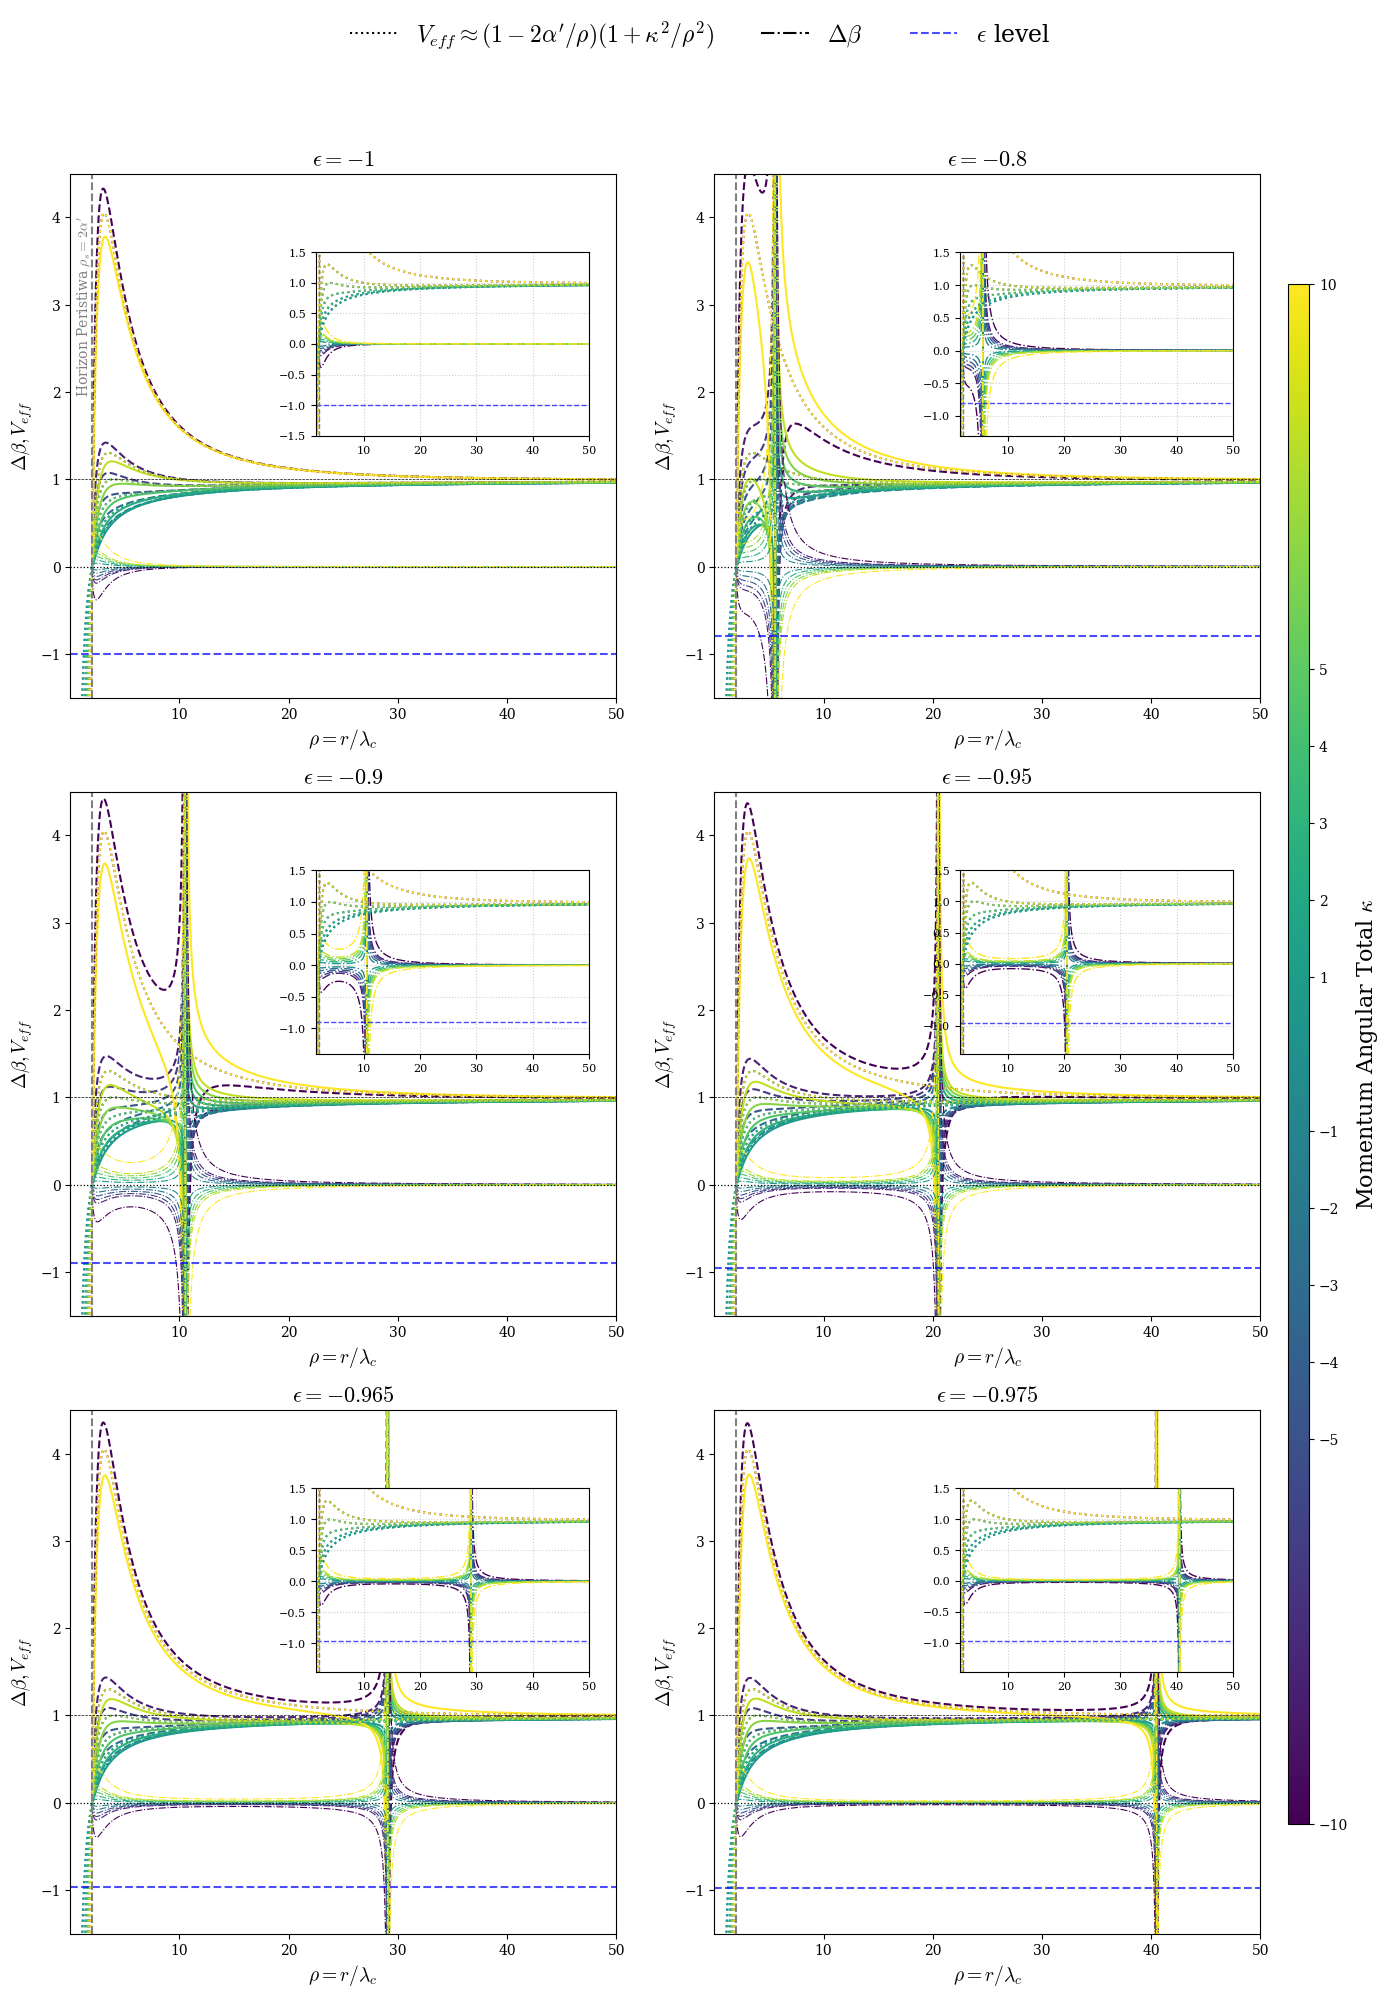

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import warnings

save_dir = './'
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# Define Parameters
alpha_prime = 1.0               # Scale parameter (GM)
epsilons = [-1, -0.8, -0.9, -0.95, -0.965, -0.975]  # List of epsilon values
kappas = [-10, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 10]

# Define the radial grid (starts just outside the event horizon rho = 2*alpha')
rho = np.linspace(0.0001 * alpha_prime, 50 * alpha_prime, 20000)
f = 1 - 2 * alpha_prime / rho   # Schwarzschild Metric

# Create a colormap for different kappa values
colors = cm.viridis(np.linspace(0, 1, len(kappas)))

# Create Subplots: 2 rows, 3 columns
fig, axes = plt.subplots(3, 2, figsize=(14, 22))
axes = axes.flatten() # Flatten to easily loop over them 1D

with np.errstate(invalid='ignore', divide='ignore'):
    for idx, epsilon in enumerate(epsilons):
        ax = axes[idx]

        # Reset lists to store plotting data for current subplot
        v_eff_plot_data = []
        v_eff_approx_plot_data = []
        delta_beta_plot_data = []

        for i, kappa in enumerate(kappas):
            delta_beta   = kappa * np.sqrt(f) * ( (alpha_prime / rho**3) / (1 + np.sqrt(f) / epsilon) - (f / rho**2) )
            V_eff        = f * (1 + kappa**2 / rho**2) - delta_beta
            V_eff_approx = f * (1 + kappa**2 / rho**2)

            linestyle_V_eff = '--' if kappa < 0 else '-'

            # Store data for plotting
            v_eff_plot_data.append({'rho': rho, 'V_eff': V_eff, 'color': colors[i], 'linestyle': linestyle_V_eff})
            v_eff_approx_plot_data.append({'rho': rho, 'V_eff_approx': V_eff_approx, 'color': colors[i]})
            delta_beta_plot_data.append({'rho': rho, 'delta_beta': delta_beta, 'color': colors[i]})

        # --- Main Plotting for current axis ---
        for data in v_eff_plot_data:
            ax.plot(data['rho'], data['V_eff'], color=data['color'], linewidth=1.5, linestyle=data['linestyle'])

        for data in v_eff_approx_plot_data:
            ax.plot(data['rho'], data['V_eff_approx'], color=data['color'], linewidth=1.5, linestyle=':')

        for data in delta_beta_plot_data:
             ax.plot(data['rho'], data['delta_beta'], color=data['color'], linewidth=0.8, linestyle='-.')

        ax.set_xlabel(r'$\rho = r/\lambda_c $', fontsize=14)
        ax.set_ylabel(r'$\Delta\beta,V_{{eff}}$', fontsize=14)
        ax.set_title(rf'$\epsilon = {epsilon}$', fontsize=16, fontweight='bold')

        # Add reference lines
        ax.axhline(1, color='black', linewidth=0.5, linestyle='--')
        ax.axhline(0, color='black', linewidth=0.9, linestyle=':')
        line_eps = ax.axhline(epsilon, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label=rf' $\epsilon = {epsilon}$')
        ax.axvline( 2 * alpha_prime , color='gray', linestyle='--', linewidth=1.5)

        # Only add the text to the first subplot to prevent clutter
        if idx == 0:
            ax.text( 2 * alpha_prime - 1.5 , 2, r'Horizon Peristiwa $\rho_s = 2\alpha^{\prime}$', rotation=90, color='gray', fontsize=10)

        # Plot limits
        ax.set_ylim(-1.5, 4.5)
        ax.set_xlim(rho.min(), rho.max())

        # --- Inset Zoomed Plot ---
        # Using inset_axes so it places perfectly relative to each subplot
        ax_inset = ax.inset_axes([0.45, 0.50, 0.50, 0.35])

        for data in delta_beta_plot_data:
            ax_inset.plot(data['rho'], data['delta_beta'], color=data['color'], linewidth=1.0, linestyle='-.')

        for data in v_eff_approx_plot_data:
            ax_inset.plot(data['rho'], data['V_eff_approx'], color=data['color'], linewidth=1.5, linestyle=':')

        ax_inset.axhline(epsilon, color='blue', linestyle='--', linewidth=1.0, alpha=0.7)
        ax_inset.axvline(2 * alpha_prime, color='gray', linestyle='--', linewidth=1.0)
        ax_inset.set_xlim(1.5 * alpha_prime, 50 * alpha_prime)
        ax_inset.set_ylim(epsilon - 0.5, 1.5) # Dynamic y-lim for inset based on epsilon
        ax_inset.tick_params(axis='both', which='major', labelsize=8)
        ax_inset.grid(True, linestyle=':', alpha=0.6)

# --- Global Legend and Colorbar ---
# Create proxy artists for the main line styles in the legend
proxy_handles = [
    plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label=r'$V_{{{eff}}}\approx(1-2\alpha^{\prime}/\rho)(1 + \kappa^2/\rho^2)$'),
    plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='-.', label=r'$\Delta\beta$'),
    plt.Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label=r'$\epsilon$ level')
]

# Add a single legend to the overall figure
fig.legend(handles=proxy_handles, loc='upper center', ncol=3, fontsize=17, frameon=False, bbox_to_anchor=(0.5, 0.98))

# Create a single colorbar for all subplots
norm = mcolors.Normalize(vmin=min(kappas), vmax=max(kappas))
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array(kappas)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label(r'Momentum Angular Total $\kappa$', fontsize=16)
cbar.set_ticks(kappas)

# Adjust layout so elements do not overlap
plt.subplots_adjust(top=0.90, bottom=0.1, left=0.05, right=0.90, hspace=0.18, wspace=0.18)

filename = os.path.join(save_dir, 'Effective_potential_Deltabeta_All_Epsilons.png')
plt.savefig(filename, dpi=350)
plt.show()

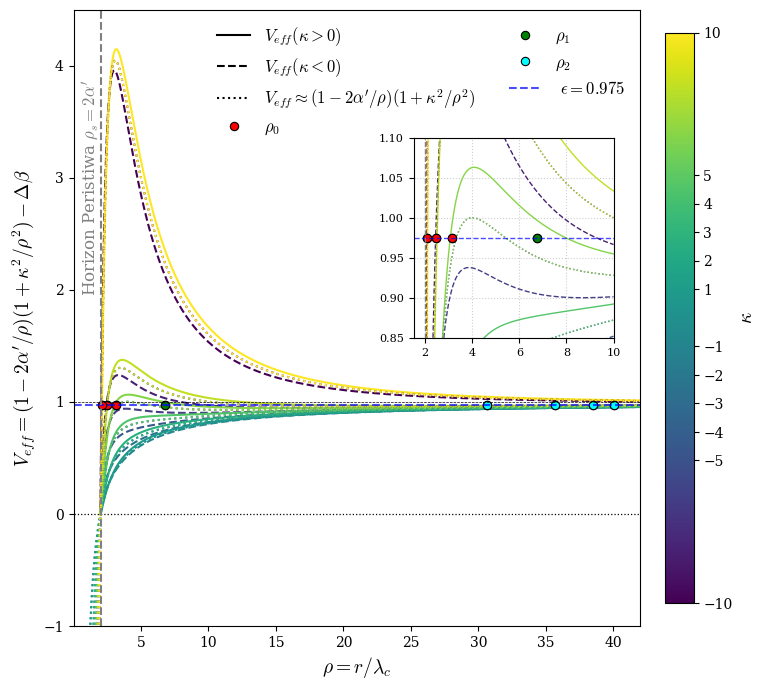


Sorted all roots for ε = 0.975:


,κ,ρ_0,ρ_1,ρ_2
0,-10,2.082258+0.000000j,19.212035-39.701452j,19.212035+39.701452j
1,-5,2.451796+0.000000j,19.027267- 7.140749j,19.027267+ 7.140749j
2,-4,3.129949+0.000000j,6.764097+ 0.000000j,30.612282+ 0.000000j
3,-3,2.410879-2.098513j,2.410879+ 2.098513j,35.684570+ 0.000000j
4,-2,0.997163-1.792429j,0.997163+ 1.792429j,38.512002+ 0.000000j
5,-1,0.240361-0.976851j,0.240361+ 0.976851j,40.025608+ 0.000000j
6,1,0.240361-0.976851j,0.240361+ 0.976851j,40.025608+ 0.000000j
7,2,0.997163-1.792429j,0.997163+ 1.792429j,38.512002+ 0.000000j
8,3,2.410879-2.098513j,2.410879+ 2.098513j,35.684570+ 0.000000j
9,4,3.129949+0.000000j,6.764097+ 0.000000j,30.612282+ 0.000000j


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
from IPython.display import display
import warnings

save_dir = './'
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'


# Define Parameters
alpha_prime = 1.0               # Scale parameter (GM)
epsilon = 0.975               # Energy to rest mass ratio
kappas = [-10, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 10] # Renamed for clarity in colorbar
#kappas = [-10, -5, -2, -1, 1, 2, 5, 10]
# Plotting
fig, ax = plt.subplots(figsize=(8, 8)) # Get fig and ax objects
# Create a colormap for different kappa values
colors = cm.viridis(np.linspace(0, 1, len(kappas)))
#colors_neg = cm.Blues(np.linspace(0.4, 1, len(kappas_neg))) if kappas_neg else []
#colors_pos = cm.Oranges(np.linspace(0.4, 1, len(kappas_pos))) if kappas_pos else []
# Define the radial grid (starts just outside the event horizon rho = 2*alpha')
rho = np.linspace(0.0001 * alpha_prime, 42 * alpha_prime, 20000)
f = 1 - 2 * alpha_prime / rho   # Schwarzschild Metric

# Dictionary to store all calculated roots for later display
all_calculated_roots = {}

# Lists to store plotting data for both main and inset plots
v_eff_plot_data = []
v_eff_approx_plot_data = []
delta_beta_plot_data = []
root_plot_data = []

with np.errstate(invalid='ignore', divide='ignore'):
  for i, kappa in enumerate(kappas):

      delta_beta   = kappa * np.sqrt(f) * ( (alpha_prime / rho**3) / (1 + np.sqrt(f) / epsilon) - (f / rho**2) )
      V_eff        = f * (1 + kappa**2 / rho**2) - delta_beta
      V_eff_approx = f * (1 + kappa**2 / rho**2)

      linestyle_V_eff = '--' if kappa < 0 else '-'

      # Store data for plotting
      v_eff_plot_data.append({'rho': rho, 'V_eff': V_eff, 'color': colors[i], 'linestyle': linestyle_V_eff})
      v_eff_approx_plot_data.append({'rho': rho, 'V_eff_approx': V_eff_approx, 'color': colors[i]})
      delta_beta_plot_data.append({'rho': rho, 'delta_beta': delta_beta, 'color': colors[i]})

      # plot the approximate analytical roots (classical turning point) of the approximate potential (V_eff_approx = ε^2)
      # The equation is (ε^2-1)ρ^3 + 2α'ρ^2 - κ^2ρ + 2α'κ^2 = 0
      a_coeff = epsilon**2 - 1
      b_coeff = 2*alpha_prime
      c_coeff = -kappa**2
      d_coeff = 2*alpha_prime*kappa**2

      # Solve the cubic equation using numpy.roots
      coeffs = [a_coeff, b_coeff, c_coeff, d_coeff]
      rho_roots = np.roots(coeffs)

      # Store roots for current kappa
      all_calculated_roots[kappa] = rho_roots

      # SORT them from smallest to largest rho_0 < rho_1 < rho_2
      # Sorting the roots based on :
      # 1. real component (x.real)
      # 2. if the real component is same, sort based on imaginary comp. (x.imag)
      sorted_roots = sorted(rho_roots, key=lambda x: (x.real, x.imag))

      # Define the colors for rho_0 (red), rho_1(green), rho_2(cyan)
      root_colors = ['red', 'green', 'cyan']

      # Store valid roots for plotting
      for k_root, roots in enumerate(sorted_roots):
          if np.isreal(roots) and roots.real > 0 and np.isclose(roots.imag, 0):
            # the roots must be real because there is no imaginary classical turning point
            # the roots must be greater than zero because radial coordinate starts from zero to infinity (there is no negative radial value)
            # approximate roots which have so small imaginary component (close to zero imaginary component) to be real
              root_val = roots.real
              color = root_colors[k_root]
              root_plot_data.append({'root_val': root_val, 'epsilon': epsilon, 'color': color, 'marker_props': {'marker': 'o', 'markerfacecolor': color, 'markeredgecolor': 'black', 'markeredgewidth': 0.8, 'markersize': 6, 'linestyle': 'None'}})
          else:
              continue

# --- Main Plotting --- (after collecting all data)
for data in v_eff_plot_data:
    ax.plot(data['rho'], data['V_eff'], color=data['color'], linewidth=1.5, linestyle=data['linestyle'])

for data in v_eff_approx_plot_data:
    ax.plot(data['rho'], data['V_eff_approx'], color=data['color'], linewidth=1.5, linestyle=':')

# The delta_beta line was commented out in the original code. Uncomment if needed.
# for data in delta_beta_plot_data:
#     ax.plot(data['rho'], data['delta_beta'], color=data['color'], linewidth=0.8, linestyle='-.')

for data in root_plot_data:
    ax.plot(data['root_val'], data['epsilon'], **data['marker_props'])


ax.set_xlabel(r'$\rho = r/\lambda_c $', fontsize=14)
ax.set_ylabel(r'$V_{{eff}}=(1-2\alpha^{\prime}/\rho)(1 + \kappa^2/\rho^2)-\Delta\beta $', fontsize=14) #$\Delta\beta$,

# Add axhline for epsilon, with a label
ax.axhline(1, color='black', linewidth=0.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.9, linestyle=':')
ax.axhline(epsilon, color='blue', linestyle='--', linewidth=1.5, label=rf' $\epsilon = {epsilon}$', alpha=0.7)
ax.axvline( 2 * alpha_prime , color='gray', linestyle='--', linewidth=1.5)
ax.text( 2 * alpha_prime - 1.5 , 2, r'Horizon Peristiwa $\rho_s = 2\alpha^{\prime}$', rotation=90, color='gray', fontsize=12)

# Create proxy artists for the main line styles in the legend
proxy_handles = []
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='-', label=r'$V_{{{eff}}} (\kappa > 0)$'))
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label=r'$V_{{{eff}}} (\kappa < 0)$'))
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label=r'$V_{{{eff}}}\approx(1-2\alpha^{\prime}/\rho)(1 + \kappa^2/\rho^2)$'))
#proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='-.', label=r'$\Delta\beta$'))
proxy_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='black', markeredgewidth=0.8,  markersize=6, label=r'$\rho_0$'))
proxy_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markeredgecolor='black', markeredgewidth=0.8,  markersize=6, label=r'$\rho_1$'))
proxy_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan',  markeredgecolor='black', markeredgewidth=0.8,  markersize=6, label=r'$\rho_2$'))

# Get the handle and label for the epsilon line from the existing plot
line_epsilon_handle, line_epsilon_label = ax.get_legend_handles_labels()

# Combine proxy handles with the epsilon line handle
combined_handles = proxy_handles + line_epsilon_handle
combined_labels = [h.get_label() for h in proxy_handles] + line_epsilon_label


# Create the legend
ax.legend(handles=combined_handles, labels=combined_labels, loc='upper right', ncol=2, fontsize=12, frameon=False)

# Create a colorbar for kappa values
norm = mcolors.Normalize(vmin=min(kappas), vmax=max(kappas))
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array(kappas) # The array data must be set to ensure color mapping
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label(r'$\kappa$', fontsize=14)
cbar.set_ticks(kappas) # Set integer ticks
ax.set_ylim(-1, 4.5)
ax.set_xlim(rho.min(), rho.max())


# --- Inset Zoomed Plot ---
ax_inset = fig.add_axes([0.55, 0.47, 0.25, 0.25]) # Position and size of the inset axes

for data in v_eff_plot_data:
    ax_inset.plot(data['rho'], data['V_eff'], color=data['color'], linewidth=1.0, linestyle=data['linestyle'])

for data in v_eff_approx_plot_data:
    ax_inset.plot(data['rho'], data['V_eff_approx'], color=data['color'], linewidth=1.0, linestyle=':')

# Plot roots on inset
for data in root_plot_data:
    ax_inset.plot(data['root_val'], data['epsilon'], **data['marker_props'])

ax_inset.axhline(epsilon, color='blue', linestyle='--', linewidth=1.0, alpha=0.7)
ax_inset.axvline(2 * alpha_prime, color='gray', linestyle='--', linewidth=1.0)
ax_inset.set_xlim(1.5 * alpha_prime, 10 * alpha_prime) # Zoomed x-limits
ax_inset.set_ylim(0.85, 1.1) # Zoomed y-limits
ax_inset.tick_params(axis='both', which='major', labelsize=8)
ax_inset.grid(True, linestyle=':', alpha=0.6) # Add a grid to the inset


filename = os.path.join(save_dir, f'Effective_potential_Deltabeta_roots_{epsilon:.3f}.png')
plt.savefig(filename, dpi=350)
plt.show()

# Show all roots
data_roots = []
for kappa, roots in all_calculated_roots.items():

    # Sorting the roots based on :
    # 1. real component (x.real)
    # 2. if the real component is same, sort based on imaginary comp. (x.imag)
    sorted_roots = sorted(roots, key=lambda x: (x.real, x.imag))
    roots_rounded = np.round(sorted_roots, 7)
    data_roots.append({
        'κ': kappa,
        'ρ_0': roots_rounded[0],
        'ρ_1': roots_rounded[1],
        'ρ_2': roots_rounded[2]
    })

df_roots = pd.DataFrame(data_roots)
print(f"\nSorted all roots for ε = {epsilon}:")
display(df_roots)

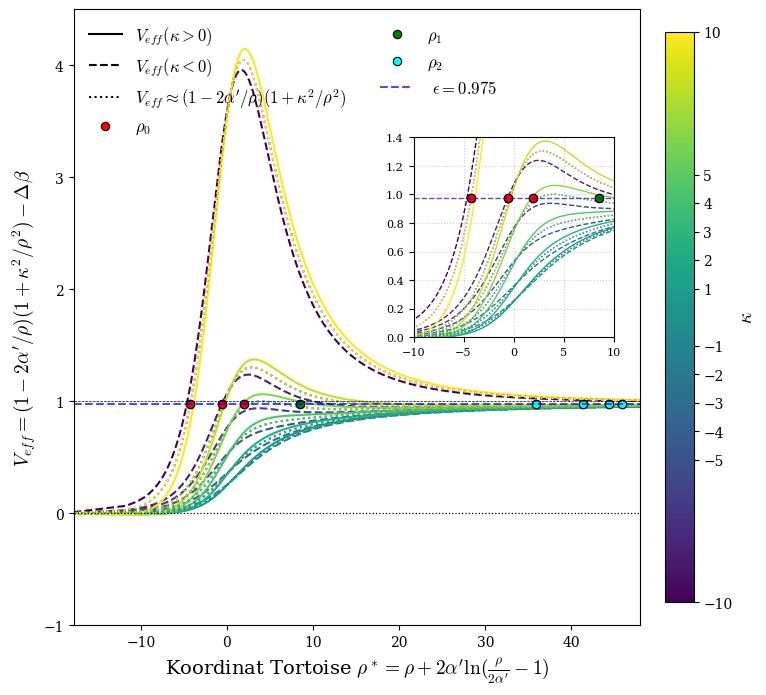


Sorted all roots (in standard ρ coordinates) for ε = 0.975:


,κ,ρ_0,ρ_1,ρ_2
0,-10,2.082258+0.000000j,19.212035-39.701452j,19.212035+39.701452j
1,-5,2.451796+0.000000j,19.027267- 7.140749j,19.027267+ 7.140749j
2,-4,3.129949+0.000000j,6.764097+ 0.000000j,30.612282+ 0.000000j
3,-3,2.410879-2.098513j,2.410879+ 2.098513j,35.684570+ 0.000000j
4,-2,0.997163-1.792429j,0.997163+ 1.792429j,38.512002+ 0.000000j
5,-1,0.240361-0.976851j,0.240361+ 0.976851j,40.025608+ 0.000000j
6,1,0.240361-0.976851j,0.240361+ 0.976851j,40.025608+ 0.000000j
7,2,0.997163-1.792429j,0.997163+ 1.792429j,38.512002+ 0.000000j
8,3,2.410879-2.098513j,2.410879+ 2.098513j,35.684570+ 0.000000j
9,4,3.129949+0.000000j,6.764097+ 0.000000j,30.612282+ 0.000000j


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
from IPython.display import display
import warnings

save_dir = './'
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# Define Parameters
alpha_prime = 1.0               # Scale parameter (GM)
epsilon = 0.975                 # Energy to rest mass ratio
kappas = [-10, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 10]

# --- Tortoise Coordinate Transformation ---
def transf_rho_star(rho):
    # This is only valid for rho > 2*alpha_prime
    return rho + 2 * alpha_prime * np.log(rho / (2 * alpha_prime) - 1)

# Plotting
fig, ax = plt.subplots(figsize=(8, 8))
colors = cm.viridis(np.linspace(0, 1, len(kappas)))

# --- CRITICAL FIX: Grid must start strictly outside the event horizon ---
# Changed starting point from 0.0001 to 2.0001 to avoid log(negative) errors
rho = np.linspace(2.0001 * alpha_prime, 42 * alpha_prime, 20000)
rho_star = transf_rho_star(rho) # Calculate tortoise coordinates globally
f = 1 - 2 * alpha_prime / rho   # Schwarzschild Metric

all_calculated_roots = {}

# Lists to store plotting data
v_eff_plot_data = []
v_eff_approx_plot_data = []
delta_beta_plot_data = []
root_plot_data = []

with np.errstate(invalid='ignore', divide='ignore'):
  for i, kappa in enumerate(kappas):

      delta_beta   = kappa * np.sqrt(f) * ( (alpha_prime / rho**3) / (1 + np.sqrt(f) / epsilon) - (f / rho**2) )
      V_eff        = f * (1 + kappa**2 / rho**2) - delta_beta
      V_eff_approx = f * (1 + kappa**2 / rho**2)

      linestyle_V_eff = '--' if kappa < 0 else '-'

      # Store data for plotting using rho_star
      v_eff_plot_data.append({'rho_star': rho_star, 'V_eff': V_eff, 'color': colors[i], 'linestyle': linestyle_V_eff})
      v_eff_approx_plot_data.append({'rho_star': rho_star, 'V_eff_approx': V_eff_approx, 'color': colors[i]})

      a_coeff = epsilon**2 - 1
      b_coeff = 2*alpha_prime
      c_coeff = -kappa**2
      d_coeff = 2*alpha_prime*kappa**2

      coeffs = [a_coeff, b_coeff, c_coeff, d_coeff]
      rho_roots = np.roots(coeffs)
      all_calculated_roots[kappa] = rho_roots

      sorted_roots = sorted(rho_roots, key=lambda x: (x.real, x.imag))
      root_colors = ['red', 'green', 'cyan']

      # Store valid roots for plotting
      for k_root, roots in enumerate(sorted_roots):
          # Roots MUST be outside the event horizon (real > 2*alpha_prime) to be plotted in tortoise coords
          if np.isreal(roots) and roots.real > 2 * alpha_prime and np.isclose(roots.imag, 0):
              root_val = roots.real
              root_val_star = transf_rho_star(root_val) # Transform the root to tortoise coordinate
              color = root_colors[k_root]
              root_plot_data.append({'root_val_star': root_val_star, 'epsilon': epsilon, 'color': color, 'marker_props': {'marker': 'o', 'markerfacecolor': color, 'markeredgecolor': 'black', 'markeredgewidth': 0.8, 'markersize': 6, 'linestyle': 'None'}})

# --- Main Plotting ---
for data in v_eff_plot_data:
    ax.plot(data['rho_star'], data['V_eff'], color=data['color'], linewidth=1.5, linestyle=data['linestyle'])

for data in v_eff_approx_plot_data:
    ax.plot(data['rho_star'], data['V_eff_approx'], color=data['color'], linewidth=1.5, linestyle=':')

for data in root_plot_data:
    ax.plot(data['root_val_star'], data['epsilon'], **data['marker_props'])

# Updated X-axis Label
ax.set_xlabel(r'Koordinat Tortoise $\rho^* = \rho + 2\alpha^{\prime} \ln(\frac{\rho}{2\alpha^{\prime}} - 1)$', fontsize=14)
ax.set_ylabel(r'$V_{{eff}}=(1-2\alpha^{\prime}/\rho)(1 + \kappa^2/\rho^2)-\Delta\beta $', fontsize=14)

ax.axhline(1, color='black', linewidth=0.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.9, linestyle=':')
ax.axhline(epsilon, color='blue', linestyle='--', linewidth=1.5, label=rf' $\epsilon = {epsilon}$', alpha=0.7)

# REMOVED: Event horizon vertical line, as the horizon is now pushed to negative infinity.

proxy_handles = []
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='-', label=r'$V_{{{eff}}} (\kappa > 0)$'))
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label=r'$V_{{{eff}}} (\kappa < 0)$'))
proxy_handles.append(plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label=r'$V_{{{eff}}}\approx(1-2\alpha^{\prime}/\rho)(1 + \kappa^2/\rho^2)$'))
proxy_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='black', markeredgewidth=0.8,  markersize=6, label=r'$\rho_0$'))
proxy_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markeredgecolor='black', markeredgewidth=0.8,  markersize=6, label=r'$\rho_1$'))
proxy_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan',  markeredgecolor='black', markeredgewidth=0.8,  markersize=6, label=r'$\rho_2$'))

line_epsilon_handle, line_epsilon_label = ax.get_legend_handles_labels()
combined_handles = proxy_handles + line_epsilon_handle
combined_labels = [h.get_label() for h in proxy_handles] + line_epsilon_label

ax.legend(handles=combined_handles, labels=combined_labels, loc='upper left', ncol=2, fontsize=12, frameon=False)

norm = mcolors.Normalize(vmin=min(kappas), vmax=max(kappas))
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array(kappas)
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label(r'$\kappa$', fontsize=14)
cbar.set_ticks(kappas)

ax.set_ylim(-1, 4.5)
# Set appropriate x-limits for tortoise coords to see the tail stretching to -infinity
ax.set_xlim(rho_star.min(), rho_star.max())

# --- Inset Zoomed Plot ---
ax_inset = fig.add_axes([0.55, 0.47, 0.25, 0.25])

for data in v_eff_plot_data:
    ax_inset.plot(data['rho_star'], data['V_eff'], color=data['color'], linewidth=1.0, linestyle=data['linestyle'])

for data in v_eff_approx_plot_data:
    ax_inset.plot(data['rho_star'], data['V_eff_approx'], color=data['color'], linewidth=1.0, linestyle=':')

for data in root_plot_data:
    ax_inset.plot(data['root_val_star'], data['epsilon'], **data['marker_props'])

ax_inset.axhline(epsilon, color='blue', linestyle='--', linewidth=1.0, alpha=0.7)

# Adjusted inset limits for the new coordinate scale
ax_inset.set_xlim(-10, 10)
ax_inset.set_ylim(0, 1.4)
ax_inset.tick_params(axis='both', which='major', labelsize=8)
ax_inset.grid(True, linestyle=':', alpha=0.6)

filename = os.path.join(save_dir, f'Effective_potential_Deltabeta_roots_tortoise_{epsilon:.3f}.png')
plt.savefig(filename, dpi=350)
plt.show()

# Show all roots (still displaying in standard rho coordinates for clarity in the table)
data_roots = []
for kappa, roots in all_calculated_roots.items():
    sorted_roots = sorted(roots, key=lambda x: (x.real, x.imag))
    roots_rounded = np.round(sorted_roots, 7)
    data_roots.append({
        'κ': kappa,
        'ρ_0': roots_rounded[0],
        'ρ_1': roots_rounded[1],
        'ρ_2': roots_rounded[2]
    })

df_roots = pd.DataFrame(data_roots)
print(f"\nSorted all roots (in standard ρ coordinates) for ε = {epsilon}:")
display(df_roots)

In [ ]:
import pandas as pd
from IPython.display import display

# --- 1. FUNGSI FORMATTER LATEX ---
def format_to_latex_complex(val):
    if pd.isna(val):
        return ""
    # Jika real murni atau bagian imajinernya praktis nol
    if np.isreal(val) or np.isclose(val.imag, 0):
        return f"${val.real:.4f}$"

    # Jika memiliki bagian imajiner, ganti 'j' dengan 'i'
    real_part = f"{val.real:.4f}"
    imag_part = f"{abs(val.imag):.4f}i"
    sign = "+" if val.imag >= 0 else "-"
    return f"${real_part} {sign} {imag_part}$"


# --- 2. PROSES PENGUMPULAN DATA & SORTING ---
table_data = []

for kappa, roots in all_calculated_roots.items():
    # Urutkan berdasarkan nilai real, lalu imajiner
    sorted_roots = sorted(roots, key=lambda x: (x.real, x.imag))

    # Kita gunakan nama kolom sementara yang sederhana agar tidak error
    table_data.append({
        'Kappa': kappa,
        'Root_1': sorted_roots[0],
        'Root_2': sorted_roots[1],
        'Root_3': sorted_roots[2]
    })

# Buat DataFrame utama
df_roots = pd.DataFrame(table_data)

# (Opsional) Tampilkan tabel biasa di Colab
print(f"\nTabel Akar Tersortir (Real & Imajiner) untuk ε = {epsilon}:")
display(df_roots)


# --- 3. EXPORT KE FORMAT LATEX ---
df_export = df_roots.copy()

# Terapkan formatter ke kolom akar
root_columns = ['Root_1', 'Root_2', 'Root_3']
for col in root_columns:
    df_export[col] = df_export[col].apply(format_to_latex_complex)

# Format kolom Kappa
df_export['Kappa'] = df_export['Kappa'].apply(lambda x: f"${x}$")

# Ubah nama kolom (header) menjadi simbol LaTeX murni
df_export.rename(columns={
    'Kappa': r'$\kappa$',
    'Root_1': r'$\rho_1$',
    'Root_2': r'$\rho_2$',
    'Root_3': r'$\rho_3$'
}, inplace=True)

# Generate string LaTeX (escape=False agar simbol $ dan \ tidak rusak)
latex_table = df_export.to_latex(index=False, escape=False, column_format='c|ccc')

print("\n--- COPY THE CODE BELOW INTO YOUR LATEX DOCUMENT ---\n")
print(latex_table)


Tabel Akar Tersortir (Real & Imajiner) untuk ε = 0.975:


,Kappa,Root_1,Root_2,Root_3
0,-10,2.082258+0.000000j,19.212035-39.701452j,19.212035+39.701452j
1,-5,2.451796+0.000000j,19.027267- 7.140749j,19.027267+ 7.140749j
2,-4,3.129949+0.000000j,6.764097+ 0.000000j,30.612282+ 0.000000j
3,-3,2.410879-2.098513j,2.410879+ 2.098513j,35.684570+ 0.000000j
4,-2,0.997163-1.792429j,0.997163+ 1.792429j,38.512002+ 0.000000j
5,-1,0.240361-0.976851j,0.240361+ 0.976851j,40.025608+ 0.000000j
6,1,0.240361-0.976851j,0.240361+ 0.976851j,40.025608+ 0.000000j
7,2,0.997163-1.792429j,0.997163+ 1.792429j,38.512002+ 0.000000j
8,3,2.410879-2.098513j,2.410879+ 2.098513j,35.684570+ 0.000000j
9,4,3.129949+0.000000j,6.764097+ 0.000000j,30.612282+ 0.000000j



--- COPY THE CODE BELOW INTO YOUR LATEX DOCUMENT ---

\begin{tabular}{c|ccc}
\toprule
$\kappa$ & $\rho_1$ & $\rho_2$ & $\rho_3$ \\
\midrule
$-10$ & $2.0823$ & $19.2120 - 39.7015i$ & $19.2120 + 39.7015i$ \\
$-5$ & $2.4518$ & $19.0273 - 7.1407i$ & $19.0273 + 7.1407i$ \\
$-4$ & $3.1299$ & $6.7641$ & $30.6123$ \\
$-3$ & $2.4109 - 2.0985i$ & $2.4109 + 2.0985i$ & $35.6846$ \\
$-2$ & $0.9972 - 1.7924i$ & $0.9972 + 1.7924i$ & $38.5120$ \\
$-1$ & $0.2404 - 0.9769i$ & $0.2404 + 0.9769i$ & $40.0256$ \\
$1$ & $0.2404 - 0.9769i$ & $0.2404 + 0.9769i$ & $40.0256$ \\
$2$ & $0.9972 - 1.7924i$ & $0.9972 + 1.7924i$ & $38.5120$ \\
$3$ & $2.4109 - 2.0985i$ & $2.4109 + 2.0985i$ & $35.6846$ \\
$4$ & $3.1299$ & $6.7641$ & $30.6123$ \\
$5$ & $2.4518$ & $19.0273 - 7.1407i$ & $19.0273 + 7.1407i$ \\
$10$ & $2.0823$ & $19.2120 - 39.7015i$ & $19.2120 + 39.7015i$ \\
\bottomrule
\end{tabular}



### Komparasi `V_eff_approx` dan `V_eff` untuk beberapa nilai $\kappa$



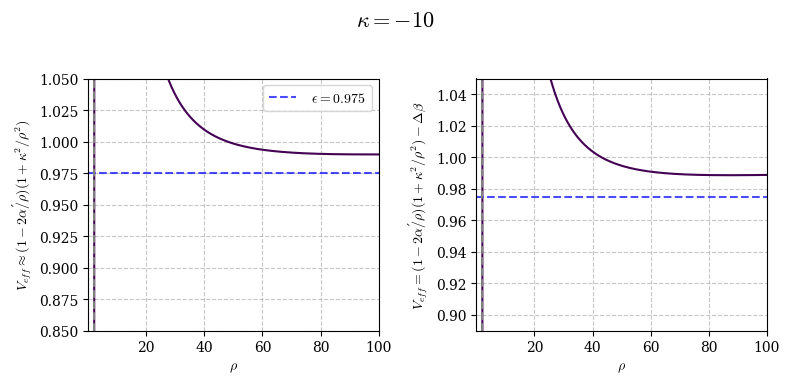

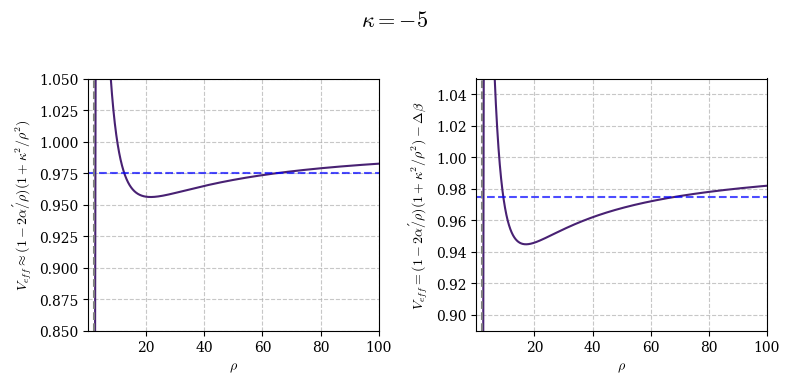

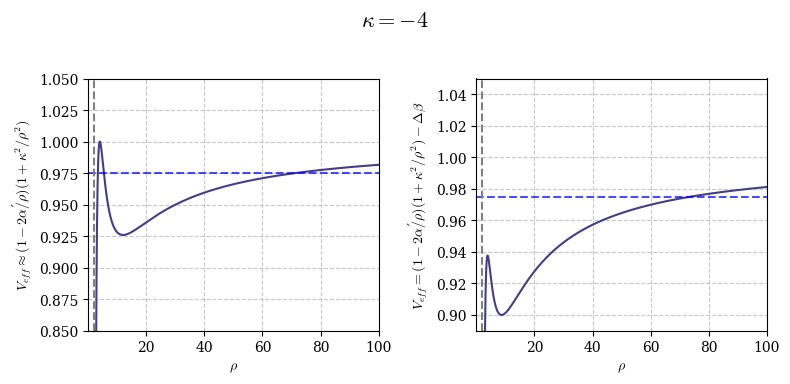

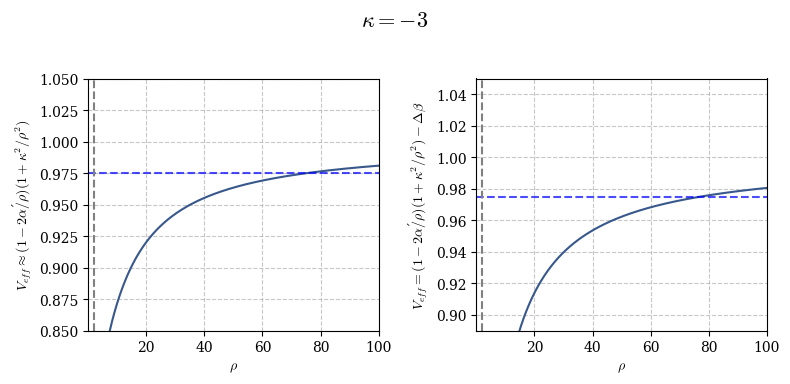

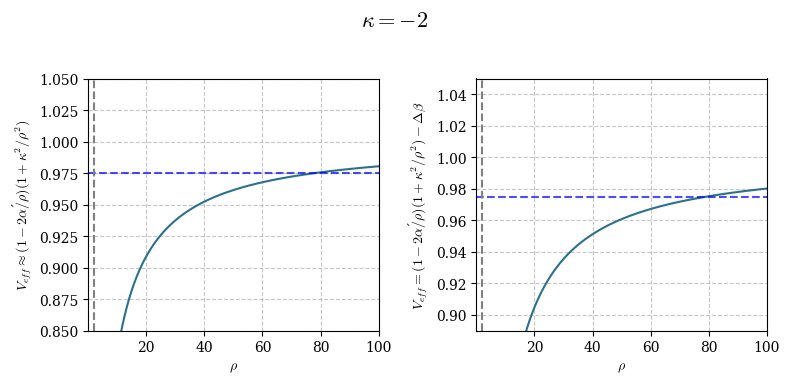

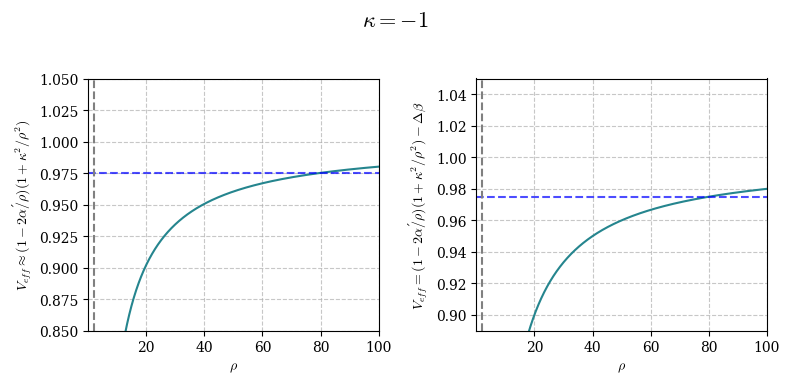

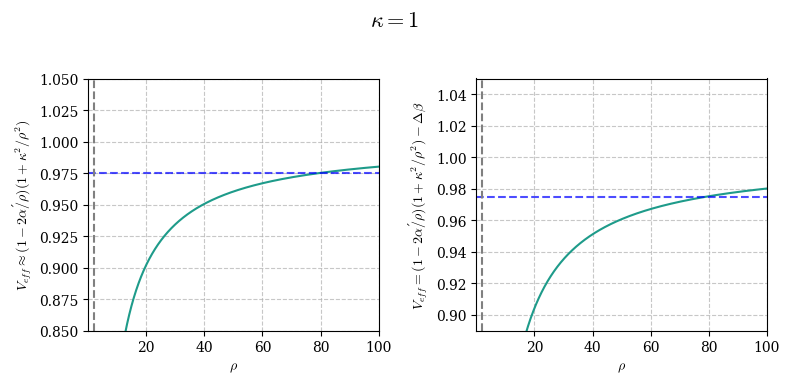

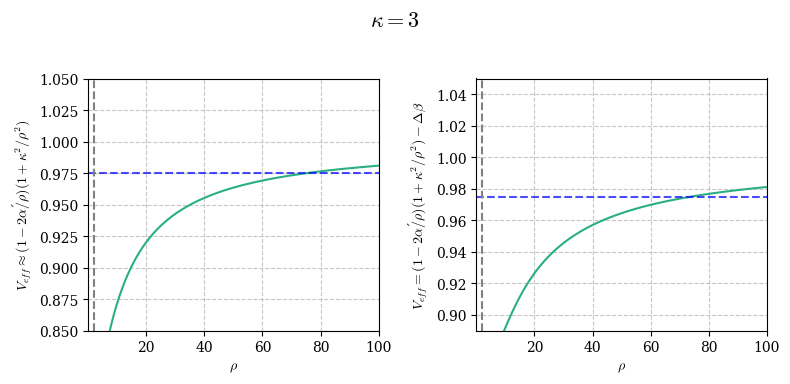

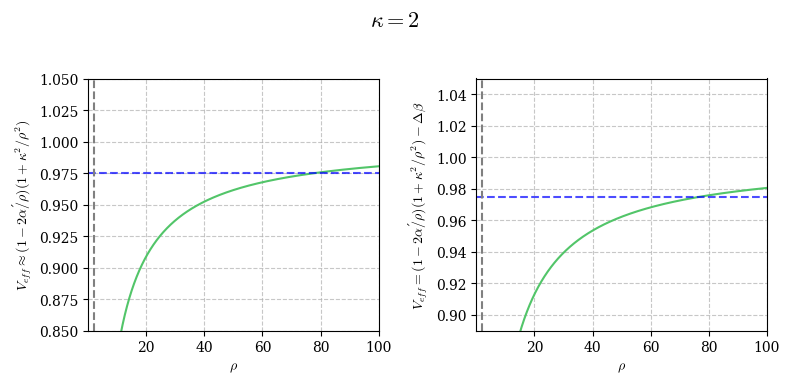

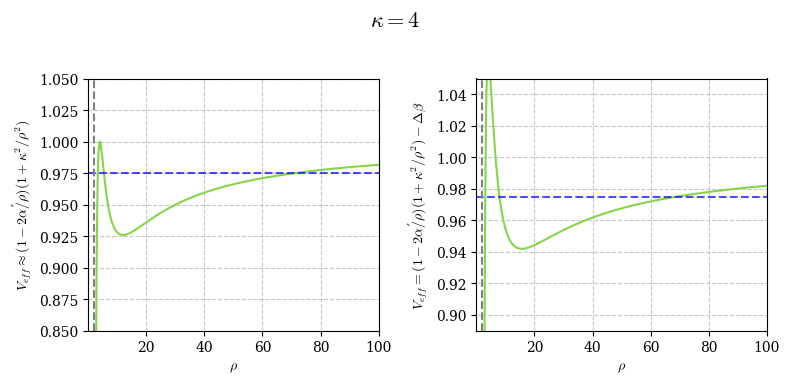

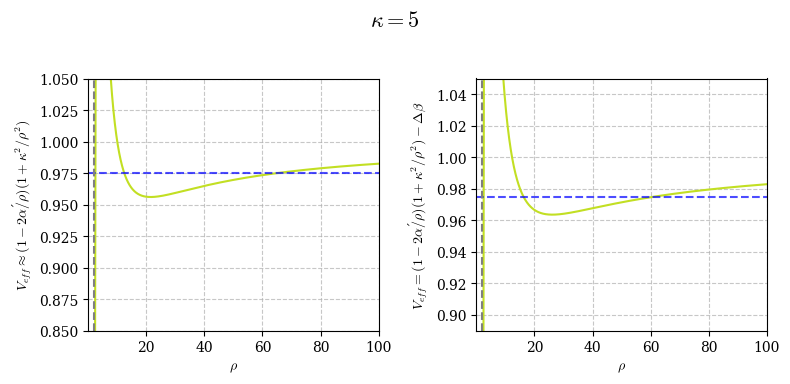

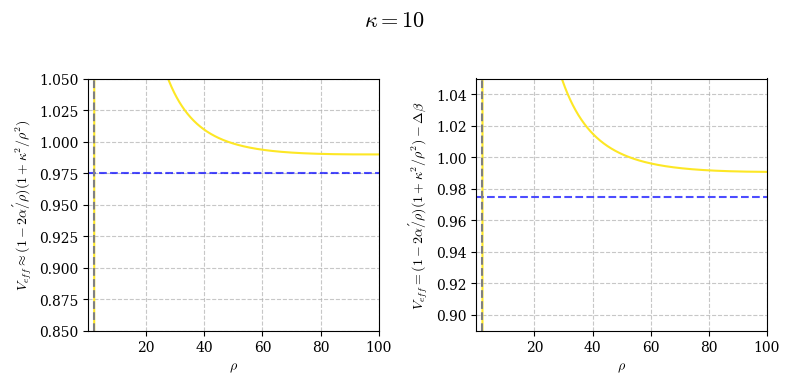

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Redefine the parameters for clarity and self-containment
alpha_prime = 1.0
epsilon = 0.975
kappas = [-10, -5, -4, -3,-2, -1, 1,3, 2, 4, 5, 10]
rho = np.linspace(0.0001 * alpha_prime, 100 * alpha_prime, 20000)
f_metric_vals = 1 - 2 * alpha_prime / rho

colors = cm.viridis(np.linspace(0, 1, len(kappas)))

for i, kappa in enumerate(kappas):
    # Calculate delta_beta and V_eff_approx for the current kappa
    # Ensuring f_metric_vals is positive for sqrt operation
    valid_f = np.where(f_metric_vals > 0, f_metric_vals, np.nan)
    sqrt_f = np.sqrt(valid_f)

    # Calculate delta_beta
    delta_beta_term = kappa * sqrt_f * ( (alpha_prime / rho**3) / (1 + sqrt_f / epsilon) - (valid_f / rho**2) )

    V_eff = valid_f * (1 + kappa**2 / rho**2) - delta_beta_term
    # Calculate V_eff_approx
    V_eff_approx_term = valid_f * (1 + kappa**2 / rho**2)

    # Create a figure with two subplots for each kappa
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(rf'$\kappa = {kappa}$', fontsize=16)

    # Plot V_eff_approx
    ax1.plot(rho, V_eff_approx_term, color=colors[i], linewidth=1.5)
    ax1.set_xlabel(r'$\rho$')
    ax1.set_ylabel(r'$V_{eff} \approx (1-2\alpha\'/\rho)(1 + \kappa^2/\rho^2)$')
    ax1.set_ylim(0.85, 1.05) # Consistent y-limit for comparison
    ax1.set_xlim(rho.min(), rho.max())
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax1.axhline(epsilon, color='blue', linestyle='--', linewidth=1.5, label=rf' $\epsilon= {epsilon}$', alpha=0.7)
    ax1.axvline(2 * alpha_prime , color='gray', linestyle='--', linewidth=1.5)
    if kappa == kappas[0]: # Add legend only once for epsilon
      ax1.legend(loc='upper right')

    # Plot V_eff
    ax2.plot(rho, V_eff, color=colors[i], linewidth=1.5)
    ax2.set_xlabel(r'$\rho$')
    ax2.set_ylabel(r'$V_{eff} = (1-2\alpha\'/\rho)(1 + \kappa^2/\rho^2)-\Delta\beta$')
    ax2.set_ylim(0.89, 1.05) # Consistent y-limit
    ax2.set_xlim(rho.min(), rho.max())
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax2.axhline(epsilon, color='blue', linestyle='--', linewidth=1.5, label=rf' $\epsilon = {epsilon}$', alpha=0.7)
    ax2.axvline(2 * alpha_prime , color='gray', linestyle='--', linewidth=1.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

# Titik Balik (*Turning Point*)

In [ ]:
import numpy as np
import csv

def calculate_V_eff(rho, kappa, epsilon, alpha_prime=1.0):
    """Computes the effective potential V_eff over a radial grid."""
    f = 1.0 - 2.0 * alpha_prime / rho
    sqrt_f = np.sqrt(f)
    delta_beta = (kappa * sqrt_f) * ((alpha_prime / rho**3) / (1.0 + sqrt_f / epsilon) - f / rho**2)
    V_eff =  f * (1.0 + kappa**2 / rho**2) - delta_beta
    return V_eff


def find_classical_turning_points():
    # 1. Setup Parameters
    alpha_prime = 1.0
    kappas = [-10,-9,-8,-7,-6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

    num_epsilon_steps = 10001
    epsilons = np.linspace(-1.1, 1.1, num_epsilon_steps)

    # Starting slightly outside the horizon to 1500
    rho_grid = np.linspace(2.001 * alpha_prime, 1500 * alpha_prime, 50000)

    # 2. Setup CSV Export
    csv_filename = '/content/drive/MyDrive/classical_turning_points.csv'

    # Open the CSV file to write the data
    with open(csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Write the Header row
        writer.writerow(['Kappa', 'Epsilon', 'Classical Turning Points (rho)'])

        print(f"Calculating and saving to {csv_filename}...")
        print(f"{'Kappa':>6} | {'Epsilon':>8} | {'Classical Turning Points (rho)':>30}")
        print("-" * 65)

        # 3. Iterate through parameter space
        for kappa in kappas:
            for eps in epsilons:
                # Skip analytical singularities
                if np.isclose(eps, 0.0) or np.isclose(eps, -1.0):
                    continue

                V_eff = calculate_V_eff(rho_grid, kappa, eps, alpha_prime)
                beta = eps**2 - V_eff

                # Find zero-crossings
                sign_changes = np.where(np.diff(np.sign(beta)))[0]

                roots = []
                for idx in sign_changes:
                    rho1, rho2 = rho_grid[idx], rho_grid[idx+1]
                    val1, val2 = beta[idx], beta[idx+1]

                    if np.isnan(val1) or np.isnan(val2) or np.abs(val1 - val2) > 100:
                        continue

                    # Refine root
                    rho_root = rho1 - val1 * (rho2 - rho1) / (val2 - val1)

                    # Convert to pure python float to remove 'np.float64' wrapper
                    clean_root = float(round(rho_root, 4))
                    roots.append(clean_root)

                # Only write to file and print if roots exist
                if roots:
                    # Print to console for monitoring
                    print(f"{kappa:6d} | {eps:8.3f} | {str(roots)}")
                    # Write row to CSV spreadsheet
                    writer.writerow([kappa, round(eps, 3), str(roots)])

    print(f"\nDone! Results saved successfully to {csv_filename}")

if __name__ == "__main__":
    find_classical_turning_points()

Streaming output truncated to the last 5000 lines.
    10 |   -0.040 | [2.004]
    10 |   -0.040 | [2.004]
    10 |   -0.040 | [2.0041]
    10 |   -0.040 | [2.0041]
    10 |   -0.039 | [2.0041]
    10 |   -0.039 | [2.0041]
    10 |   -0.039 | [2.0042]
    10 |   -0.039 | [2.0042]
    10 |   -0.038 | [2.0042]
    10 |   -0.038 | [2.0043]
    10 |   -0.038 | [2.0043]
    10 |   -0.038 | [2.0043]
    10 |   -0.038 | [2.0044]
    10 |   -0.037 | [2.0044]
    10 |   -0.037 | [2.0044]
    10 |   -0.037 | [2.0045]
    10 |   -0.037 | [2.0045]
    10 |   -0.037 | [2.0045]
    10 |   -0.036 | [2.0046]
    10 |   -0.036 | [2.0046]
    10 |   -0.036 | [2.0047]
    10 |   -0.036 | [2.0047]
    10 |   -0.035 | [2.0047]
    10 |   -0.035 | [2.0048]
    10 |   -0.035 | [2.0048]
    10 |   -0.035 | [2.0049]
    10 |   -0.035 | [2.0049]
    10 |   -0.034 | [2.005]
    10 |   -0.034 | [2.005]
    10 |   -0.034 | [2.0051]
    10 |   -0.034 | [2.0051]
    10 |   -0.033 | [2.0052]
    10 |   -0.033 | [2.00

In [10]:
import pandas as pd
import ast # To safely evaluate string representation of lists

# Load the CSV file
df_turning_points = pd.read_csv('/content/drive/MyDrive/classical_turning_points.csv')

# Convert the 'Classical Turning Points (rho)' column from string to list of floats
df_turning_points['Classical Turning Points (rho)'] = df_turning_points['Classical Turning Points (rho)'].apply(ast.literal_eval)

# Display the first few rows of the DataFrame
print("DataFrame head:")
display(df_turning_points)

# Display basic information about the DataFrame
print("\nDataFrame info:")
df_turning_points.info()

DataFrame head:


,Kappa,Epsilon,Classical Turning Points (rho)
0,-10,-1.100,"[2.0834, 15.6867]"
1,-10,-1.100,"[2.0833, 15.7021]"
2,-10,-1.100,"[2.0833, 15.7175]"
3,-10,-1.099,"[2.0832, 15.7331]"
4,-10,-1.099,"[2.0832, 15.7486]"
...,...,...,...
181807,10,1.099,"[2.1276, 17.2514]"
181808,10,1.099,"[2.1277, 17.2343]"
181809,10,1.100,"[2.1277, 17.2172]"
181810,10,1.100,"[2.1278, 17.2002]"



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181812 entries, 0 to 181811
Data columns (total 3 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Kappa                           181812 non-null  int64  
 1   Epsilon                         181812 non-null  float64
 2   Classical Turning Points (rho)  181812 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 4.2+ MB


In [11]:
# Find the maximum number of turning points in any list
max_turning_points = df_turning_points['Classical Turning Points (rho)'].apply(len).max()

# Create new columns by applying a lambda function that extracts elements from the list
for i in range(max_turning_points):
    df_turning_points[f'Turning_Point_{i+1}'] = df_turning_points['Classical Turning Points (rho)'].apply(lambda x: x[i] if len(x) > i else np.nan)

# Optionally, drop the original list column if it's no longer needed
# df_turning_points = df_turning_points.drop(columns=['Classical Turning Points (rho)'])

print(f"DataFrame with separated turning points (first {max_turning_points} columns added):")
display(df_turning_points)

DataFrame with separated turning points (first 5 columns added):


,Kappa,Epsilon,Classical Turning Points (rho),Turning_Point_1,Turning_Point_2,Turning_Point_3,Turning_Point_4,Turning_Point_5
0,-10,-1.100,"[2.0834, 15.6867]",2.0834,15.6867,NaN,NaN,NaN
1,-10,-1.100,"[2.0833, 15.7021]",2.0833,15.7021,NaN,NaN,NaN
2,-10,-1.100,"[2.0833, 15.7175]",2.0833,15.7175,NaN,NaN,NaN
3,-10,-1.099,"[2.0832, 15.7331]",2.0832,15.7331,NaN,NaN,NaN
4,-10,-1.099,"[2.0832, 15.7486]",2.0832,15.7486,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
181807,10,1.099,"[2.1276, 17.2514]",2.1276,17.2514,NaN,NaN,NaN
181808,10,1.099,"[2.1277, 17.2343]",2.1277,17.2343,NaN,NaN,NaN
181809,10,1.100,"[2.1277, 17.2172]",2.1277,17.2172,NaN,NaN,NaN
181810,10,1.100,"[2.1278, 17.2002]",2.1278,17.2002,NaN,NaN,NaN


In [ ]:
output_excel_filename = '/content/drive/MyDrive/classical_turning_points.xlsx'
df_turning_points.to_excel(output_excel_filename, index=False)
print(f"Successfully converted to Excel: {output_excel_filename}")

Successfully converted to Excel: /content/drive/MyDrive/classical_turning_points.xlsx


Now that the data is loaded and the turning points are parsed, let's explore the number of turning points for different `Kappa` and `Epsilon` values. We can also visualize how the turning points change with `Epsilon` for various `Kappa` values.

Distribution of Number of Turning Points:


,count
Num_Turning_Points,
1,108417
2,31782
3,41226
4,17
5,370


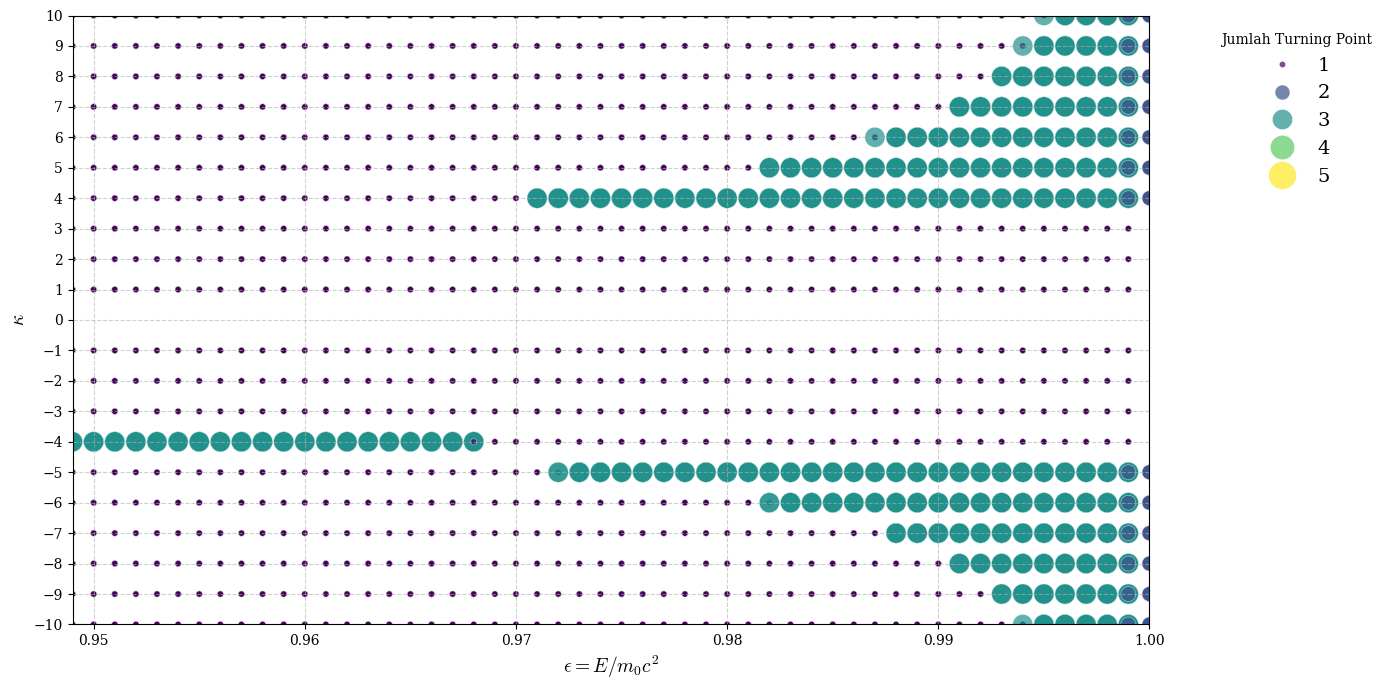

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add a column for the number of turning points
df_turning_points['Num_Turning_Points'] = df_turning_points['Classical Turning Points (rho)'].apply(len)

# Analyze the distribution of the number of turning points
print("Distribution of Number of Turning Points:")
display(df_turning_points['Num_Turning_Points'].value_counts().sort_index())

# Visualize the relationship between Kappa, Epsilon, and the number of turning points
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_turning_points,
    x='Epsilon',
    y='Kappa',
    hue='Num_Turning_Points',
    size='Num_Turning_Points',
    sizes=(20, 400), # Adjust size range for better visibility
    palette='viridis',
    alpha=0.7
)
# plt.title('Number of Classical Turning Points (rho) as a function of Kappa and Epsilon')
plt.xlabel(r'$\epsilon = E/m_0c^2$', fontsize=14)
plt.ylabel(r'$\kappa$', fontsize=14)
plt.ylim(-10, 10)
plt.yticks(range(-10, 11, 1)) # Set y-axis ticks to integers
plt.xlim(0.949, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title=r'Jumlah Turning Point',fontsize=14 , bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)
plt.tight_layout()
plt.show()